# AI Waste Sorter

### Project Overview
In this project we try to build an AI model that can classify the kind of waste into 12 classes from images.

This notebook is for comparing result of each three CNN models which trained before in order to pick the best CNN model that wil be compared with pre trained models

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [10]:
BASE_DIR = Path.cwd()
MODELS_DIR = BASE_DIR / 'models'

print(f"Models directory: {MODELS_DIR}")
print(f"Directory exists: {MODELS_DIR.exists()}")

Models directory: /mnt/d/personal/AI and Machine Learning/waste sorter ai/models
Directory exists: True


In [11]:
simple_results = None
medium_results = None
deep_results = None

if (MODELS_DIR / 'simple_cnn_results.json').exists():
    with open(MODELS_DIR / 'simple_cnn_results.json', 'r') as f:
        simple_results = json.load(f)
    print("Simple CNN results loaded")
else:
    print("Simple CNN results not found")

if (MODELS_DIR / 'medium_cnn_results.json').exists():
    with open(MODELS_DIR / 'medium_cnn_results.json', 'r') as f:
        medium_results = json.load(f)
    print("Medium CNN results loaded")
else:
    print("Medium CNN results not found")

if (MODELS_DIR / 'deep_cnn_results.json').exists():
    with open(MODELS_DIR / 'deep_cnn_results.json', 'r') as f:
        deep_results = json.load(f)
    print("Deep CNN results loaded")
else:
    print("Deep CNN results not found")

Simple CNN results loaded
Medium CNN results loaded
Deep CNN results loaded


In [12]:
models_data = []

if simple_results:
    models_data.append({
        'Model': 'Simple CNN',
        'Parameters': simple_results['parameters'],
        'Test Accuracy': simple_results['test_accuracy'],
        'Best Val Accuracy': simple_results['best_val_accuracy'],
        'Final Train Accuracy': simple_results['final_train_accuracy'],
        'Epochs Trained': simple_results['epochs_trained']
    })

if medium_results:
    models_data.append({
        'Model': 'Medium CNN',
        'Parameters': medium_results['parameters'],
        'Test Accuracy': medium_results['test_accuracy'],
        'Best Val Accuracy': medium_results['best_val_accuracy'],
        'Final Train Accuracy': medium_results['final_train_accuracy'],
        'Epochs Trained': medium_results['epochs_trained']
    })

if deep_results:
    models_data.append({
        'Model': 'Deep CNN',
        'Parameters': deep_results['parameters'],
        'Test Accuracy': deep_results['test_accuracy'],
        'Best Val Accuracy': deep_results['best_val_accuracy'],
        'Final Train Accuracy': deep_results['final_train_accuracy'],
        'Epochs Trained': deep_results['epochs_trained']
    })

if models_data:
    comparison_df = pd.DataFrame(models_data)
    comparison_df['Parameters (M)'] = comparison_df['Parameters'] / 1e6
    
    print("\nModel Comparison:")
    print(comparison_df.to_string(index=False))
    
    best_model_idx = comparison_df['Test Accuracy'].idxmax()
    best_model_name = comparison_df.loc[best_model_idx, 'Model']
    best_accuracy = comparison_df.loc[best_model_idx, 'Test Accuracy']
    
    print(f"\nBest Model: {best_model_name} with {best_accuracy:.4f} test accuracy")
else:
    print("\nNo model results found.")


Model Comparison:
     Model  Parameters  Test Accuracy  Best Val Accuracy  Final Train Accuracy  Epochs Trained  Parameters (M)
Simple CNN    25788620       0.803342           0.815484              0.799739             100       25.788620
Medium CNN    26412204       0.852185           0.863871              0.831078             100       26.412204
  Deep CNN    28584620       0.836118           0.843871              0.812441             100       28.584620

Best Model: Medium CNN with 0.8522 test accuracy


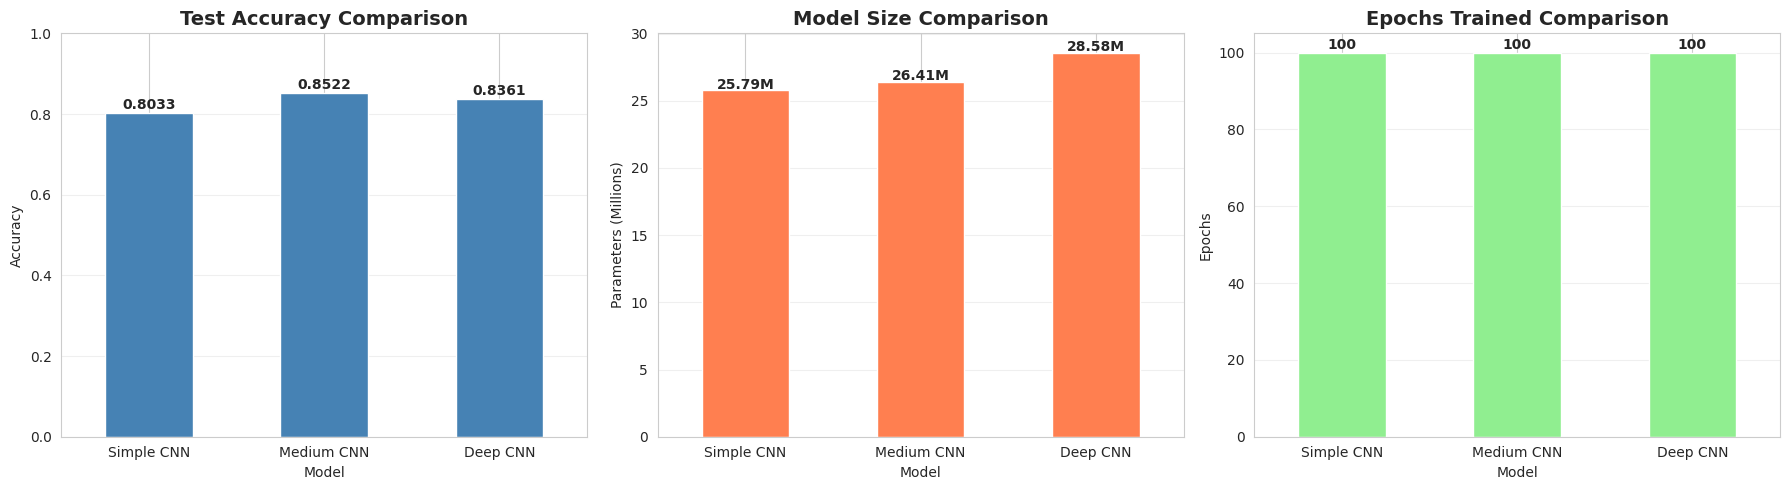

In [13]:
if models_data:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    comparison_df.plot(x='Model', y='Test Accuracy', kind='bar', ax=axes[0], color='steelblue', legend=False)
    axes[0].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Model')
    axes[0].set_ylim([0, 1])
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(comparison_df['Test Accuracy']):
        axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
    
    comparison_df.plot(x='Model', y='Parameters (M)', kind='bar', ax=axes[1], color='coral', legend=False)
    axes[1].set_title('Model Size Comparison', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Parameters (Millions)')
    axes[1].set_xlabel('Model')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(comparison_df['Parameters (M)']):
        axes[1].text(i, v + 0.1, f'{v:.2f}M', ha='center', fontweight='bold')
    
    comparison_df.plot(x='Model', y='Epochs Trained', kind='bar', ax=axes[2], color='lightgreen', legend=False)
    axes[2].set_title('Epochs Trained Comparison', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Epochs')
    axes[2].set_xlabel('Model')
    axes[2].tick_params(axis='x', rotation=0)
    axes[2].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(comparison_df['Epochs Trained']):
        axes[2].text(i, v + 1, f'{v}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'models_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

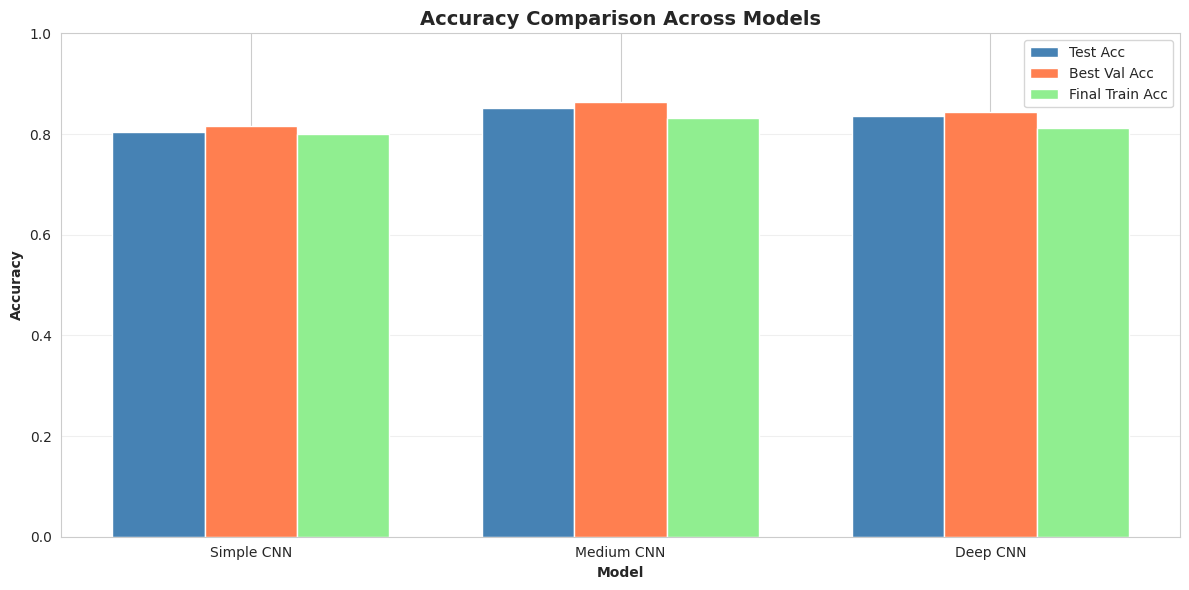

In [14]:
if models_data:
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    x = np.arange(len(comparison_df))
    width = 0.25
    
    ax.bar(x - width, comparison_df['Test Accuracy'], width, label='Test Acc', color='steelblue')
    ax.bar(x, comparison_df['Best Val Accuracy'], width, label='Best Val Acc', color='coral')
    ax.bar(x + width, comparison_df['Final Train Accuracy'], width, label='Final Train Acc', color='lightgreen')
    
    ax.set_xlabel('Model', fontweight='bold')
    ax.set_ylabel('Accuracy', fontweight='bold')
    ax.set_title('Accuracy Comparison Across Models', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df['Model'])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

In [15]:
if models_data:
    comparison_df.to_csv(MODELS_DIR / 'models_comparison.csv', index=False)
    print("Comparison saved")
    
    summary = {
        'best_model': {
            'name': best_model_name,
            'test_accuracy': float(best_accuracy),
            'parameters': int(comparison_df.loc[best_model_idx, 'Parameters'])
        },
        'all_models': models_data
    }
    
    with open(MODELS_DIR / 'cnn_training_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    
    print("Summary saved")

Comparison saved
Summary saved


In [16]:
if models_data:
    print("\nSummary")
    print(f"\nTotal models trained: {len(models_data)}")
    print(f"Best model: {best_model_name}")
    print(f"Best test accuracy: {best_accuracy:.4f}")
    print("\nAll models:")
    for model in models_data:
        print(f"  - {model['Model']}: {model['Test Accuracy']:.4f} accuracy, {model['Parameters']:,} parameters")
else:
    print("No models")


Summary

Total models trained: 3
Best model: Medium CNN
Best test accuracy: 0.8522

All models:
  - Simple CNN: 0.8033 accuracy, 25,788,620 parameters
  - Medium CNN: 0.8522 accuracy, 26,412,204 parameters
  - Deep CNN: 0.8361 accuracy, 28,584,620 parameters
